## Load Data

In [1]:
import pandas as pd

analytics_jobs = pd.read_csv(
    "../data/processed/analytics_jobs.csv"
)

## Create Model Dataset

In [2]:
model_df = analytics_jobs[
    [
        'title',
        'formatted_experience_level',
        'work_type',
        'location',
        'normalized_salary'
    ]
].dropna()

print(model_df.shape)

(435, 5)


## Salary Distribution Analysis

In [3]:
model_df['normalized_salary'].describe()

count    4.350000e+02
mean     1.440136e+05
std      3.276605e+05
min      3.250000e+01
25%      9.700200e+04
50%      1.250000e+05
75%      1.560000e+05
max      6.900400e+06
Name: normalized_salary, dtype: float64

In [4]:
model_df['normalized_salary'].quantile(
    [0.01,0.05,0.25,0.5,0.75,0.95,0.99]
)

0.01     46467.2
0.05     68109.6
0.25     97002.0
0.50    125000.0
0.75    156000.0
0.95    216745.0
0.99    240750.0
Name: normalized_salary, dtype: float64

## Remove Outliers

In [5]:
model_df_clean = model_df[
    (model_df['normalized_salary'] >= 45000) &
    (model_df['normalized_salary'] <= 250000)
]

print(model_df_clean.shape)

(428, 5)


## Feature Engineering

In [6]:
X = model_df_clean[
    [
        'title',
        'formatted_experience_level',
        'work_type',
        'location'
    ]
]

y = model_df_clean['normalized_salary']

## One-Hot Encoding

In [8]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True
)

print(X_encoded.shape)

(428, 428)


## Train-Test Split

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

## Linear Regression

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

MAE: 28945.629120511425
R²: 0.10871596314007281


## Random Forest

In [11]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("R²:", r2_score(y_test, y_pred_rf))

MAE: 25882.102647655967
R²: 0.23351209575922793


## Feature Importance

In [12]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
251,formatted_experience_level_Mid-Senior level,0.079886
252,work_type_FULL_TIME,0.062618
392,"location_San Francisco, CA",0.031720
355,"location_New York, NY",0.029200
56,title_Data Analyst,0.024968
98,title_Data Scientist,0.022662
155,title_Machine Learning Engineer,0.021131
347,"location_Mountain View, CA",0.020084
93,title_Data Engineering Director,0.018326
248,formatted_experience_level_Director,0.018005


<Figure size 1000x600 with 0 Axes>

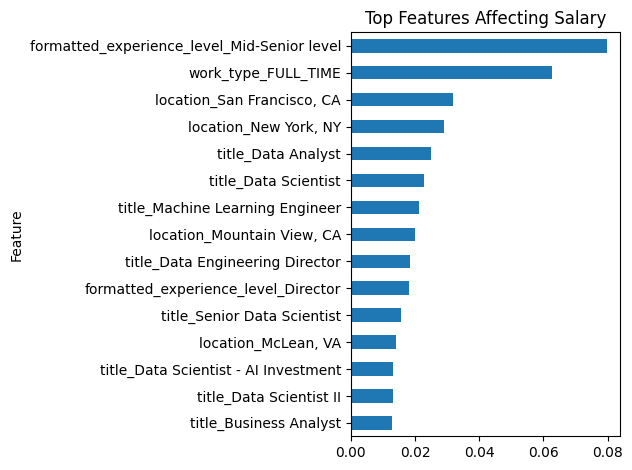

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

feature_importance.head(15).sort_values(
    by='Importance'
).plot(
    x='Feature',
    y='Importance',
    kind='barh',
    legend=False
)

plt.title("Top Features Affecting Salary")
plt.tight_layout()
plt.show()

## Model Comparison


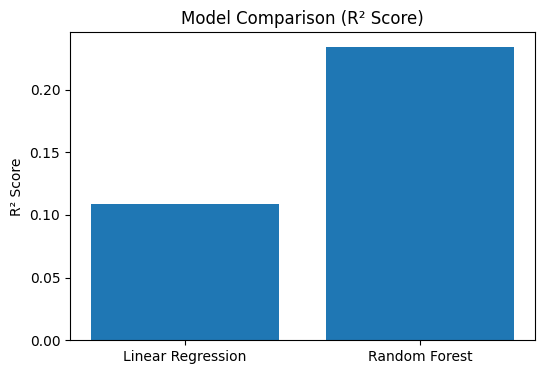

In [15]:
import matplotlib.pyplot as plt

models = ["Linear Regression", "Random Forest"]
r2 = [0.109, 0.234]

plt.figure(figsize=(6,4))
plt.bar(models, r2)
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()

After removing salary outliers, both models improved substantially. Random Forest achieved the best performance and was selected as the final model due to its lower prediction error and higher explanatory power.

In [14]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(rf, "../models/salary_predictor.pkl")
joblib.dump(X_encoded.columns.tolist(),
            "../models/model_columns.pkl")

print("Model saved successfully!")

Model saved successfully!
